# World Happiness Report 2026 — Exploratory Data Analysis

**Analytical question:**
What socio-economic factors are associated with differences in life satisfaction across countries, and how have these relationships evolved over time (2011–2025)?

**Data source:** World Happiness Report 2026, Data for Figure 2.1 (official, free release).
Covers 168 countries, years 2011–2025 (no data for 2013), with:
- `Life evaluation (3-year average)` — the happiness score (0–10)
- Six explanatory factors (GDP, social support, healthy life expectancy, freedom, generosity, perceptions of corruption)
- `Dystopia + residual` — baseline + unexplained variance

**Structure of this notebook:**
1. Data understanding
2. Data cleaning
3. Exploratory analysis (2025 snapshot)
4. Relationship between happiness and each factor
5. Trends over time (2011–2025)
6. Key insights & next steps


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RAW_PATH = "../data/raw/WHR26_Data_Figure_2_1_Data_for_Figure_2.csv"
PROCESSED_PATH = "../data/processed/happiness_clean.csv"


## 1. Data Understanding

In [2]:
df_raw = pd.read_csv(RAW_PATH, encoding="latin-1")
print(df_raw.shape)
df_raw.head()


(2116, 28)


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# The raw export includes several trailing empty columns — inspect before dropping
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 28 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

In [4]:
# Drop fully-empty trailing columns (artifact of the CSV export)
df = df_raw.dropna(axis=1, how="all").copy()
df.columns


Index(['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)',
       'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita',
       'Explained by: Social support', 'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='str')

In [5]:
df.describe(include="all")


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,2116.000000,2116.000000,2116,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
unique,NaN,NaN,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Finland,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2018.220227,76.190926,NaN,5.465656,5.436093,5.664735,1.265671,1.096739,0.553437,0.609459,0.147342,0.144912,1.736935
std,4.249844,43.845101,NaN,1.123871,1.140963,1.107421,0.463822,0.357640,0.229984,0.212071,0.084340,0.118802,0.657502
min,2011.000000,1.000000,NaN,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,NaN,4.604750,4.619750,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063250,1.305000
50%,2018.000000,76.000000,NaN,5.480000,5.592500,5.812000,1.304000,1.140000,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,NaN,6.321250,6.290000,6.486500,1.636000,1.382000,0.712250,0.735000,0.195500,0.181000,2.178000


In [6]:
df.isna().sum()


Year                                             0
Rank                                             0
Country name                                     0
Life evaluation (3-year average)                 0
Lower whisker                                 1094
Upper whisker                                 1094
Explained by: Log GDP per capita              1097
Explained by: Social support                  1097
Explained by: Healthy life expectancy         1100
Explained by: Freedom to make life choices    1099
Explained by: Generosity                      1097
Explained by: Perceptions of corruption       1098
Dystopia + residual                           1103
dtype: int64

**Observations to fill in after running the cells above:**
- Are there missing values, and in which columns/years?
- Does every country have data for every year, or is the panel unbalanced?
- Any duplicate rows (same country + year)?


In [7]:
# Check panel balance: how many years of data does each country have?
coverage = df.groupby("Country name")["Year"].nunique().sort_values()
coverage.describe()


count    168.000000
mean      12.595238
std        3.177839
min        1.000000
25%       14.000000
50%       14.000000
75%       14.000000
max       14.000000
Name: Year, dtype: float64

In [8]:
# Duplicate check
df.duplicated(subset=["Country name", "Year"]).sum()


np.int64(0)

## 2. Data Cleaning

In [9]:
# Rename columns to clean, code-friendly names
df = df.rename(columns={
    "Life evaluation (3-year average)": "life_evaluation",
    "Lower whisker": "ci_lower",
    "Upper whisker": "ci_upper",
    "Explained by: Log GDP per capita": "gdp_per_capita",
    "Explained by: Social support": "social_support",
    "Explained by: Healthy life expectancy": "healthy_life_expectancy",
    "Explained by: Freedom to make life choices": "freedom",
    "Explained by: Generosity": "generosity",
    "Explained by: Perceptions of corruption": "corruption_perception",
    "Dystopia + residual": "dystopia_residual",
    "Country name": "country",
    "Year": "year",
    "Rank": "rank",
})
df.columns


Index(['year', 'rank', 'country', 'life_evaluation', 'ci_lower', 'ci_upper',
       'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
       'freedom', 'generosity', 'corruption_perception', 'dystopia_residual'],
      dtype='str')

In [10]:
# Save the cleaned dataset for reuse in later notebooks / scripts
df.to_csv(PROCESSED_PATH, index=False)
df.head()


,year,rank,country,life_evaluation,ci_lower,ci_upper,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception,dystopia_residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


## 3. Exploratory Analysis — 2025 Snapshot

In [11]:
df_2025 = df[df["year"] == 2025].sort_values("life_evaluation", ascending=False)
df_2025.head(10)


,year,rank,country,life_evaluation,ci_lower,ci_upper,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception,dystopia_residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041
5,2025,6,Norway,7.242,7.156,7.327,2.057,1.626,0.983,1.092,0.157,0.413,0.913
6,2025,7,Netherlands,7.223,7.153,7.293,1.983,1.539,0.922,1.000,0.175,0.349,1.255
7,2025,8,Israel,7.187,7.119,7.254,1.867,1.606,0.925,0.863,0.139,0.196,1.592
8,2025,9,Luxembourg,7.063,6.971,7.154,2.162,1.465,0.981,1.056,0.111,0.382,0.907
9,2025,10,Switzerland,7.018,6.937,7.099,2.028,1.534,1.017,1.035,0.148,0.452,0.804


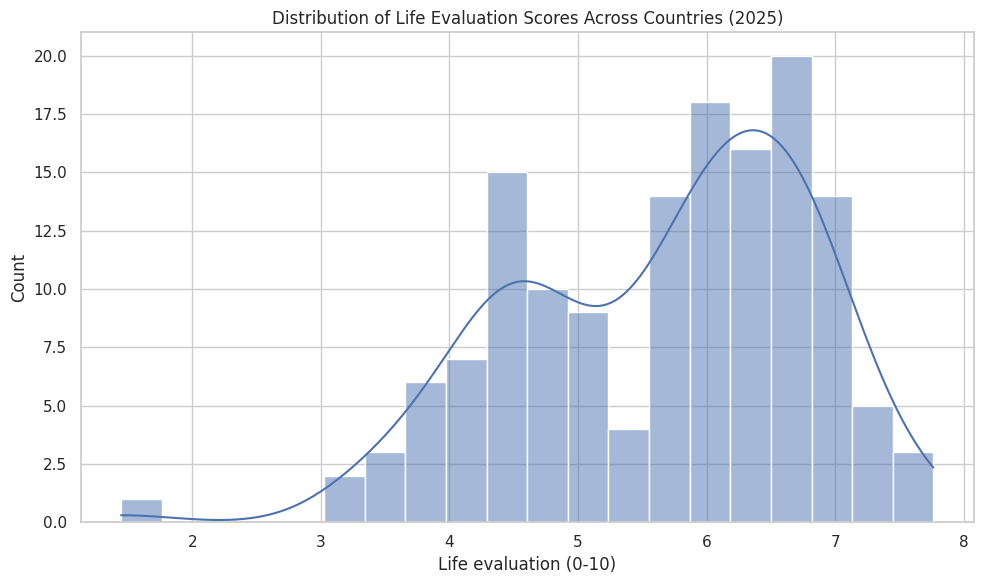

In [12]:
fig, ax = plt.subplots()
sns.histplot(df_2025["life_evaluation"], bins=20, kde=True, ax=ax)
ax.set_title("Distribution of Life Evaluation Scores Across Countries (2025)")
ax.set_xlabel("Life evaluation (0-10)")
plt.tight_layout()
plt.savefig("../visuals/happiness_distribution_2025.png", dpi=150)
plt.show()


/tmp/ipykernel_547/4028621072.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, y="country", x="life_evaluation", ax=axes[0], palette="Greens_r")
/tmp/ipykernel_547/4028621072.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom15, y="country", x="life_evaluation", ax=axes[1], palette="Reds")


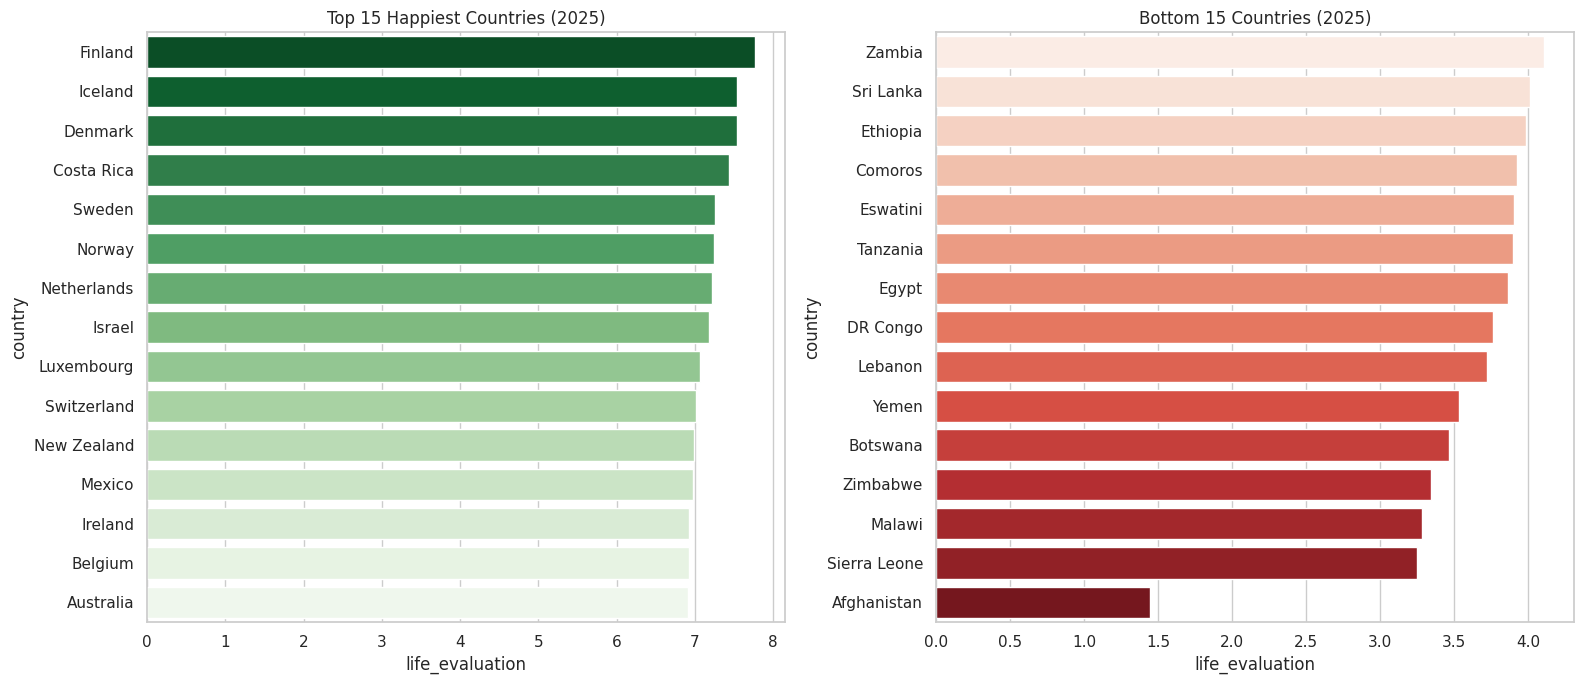

In [13]:
top15 = df_2025.head(15)
bottom15 = df_2025.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=top15, y="country", x="life_evaluation", ax=axes[0], palette="Greens_r")
axes[0].set_title("Top 15 Happiest Countries (2025)")

sns.barplot(data=bottom15, y="country", x="life_evaluation", ax=axes[1], palette="Reds")
axes[1].set_title("Bottom 15 Countries (2025)")

plt.tight_layout()
plt.savefig("../visuals/top_bottom_countries_2025.png", dpi=150)
plt.show()


## 4. Which Factors Are Most Associated With Happiness?

In [14]:
factor_cols = [
    "gdp_per_capita", "social_support", "healthy_life_expectancy",
    "freedom", "generosity", "corruption_perception",
]

corr = df_2025[["life_evaluation"] + factor_cols].corr()
corr


,life_evaluation,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception
life_evaluation,1.000000,0.744550,0.805444,0.677526,0.639757,0.041858,0.392491
gdp_per_capita,0.744550,1.000000,0.682896,0.688204,0.385323,-0.084024,0.359851
social_support,0.805444,0.682896,1.000000,0.529951,0.456429,0.005953,0.221521
healthy_life_expectancy,0.677526,0.688204,0.529951,1.000000,0.341593,0.075675,0.500702
freedom,0.639757,0.385323,0.456429,0.341593,1.000000,0.129081,0.294674
generosity,0.041858,-0.084024,0.005953,0.075675,0.129081,1.000000,0.174897
corruption_perception,0.392491,0.359851,0.221521,0.500702,0.294674,0.174897,1.000000


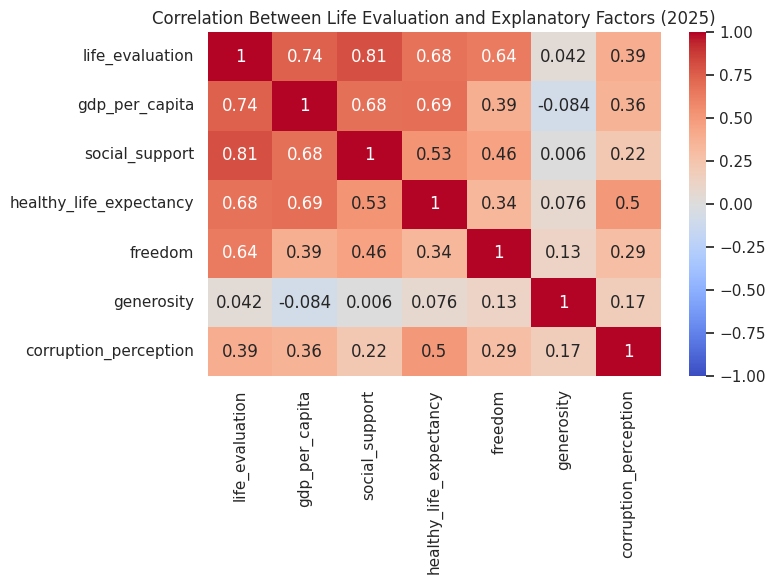

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Between Life Evaluation and Explanatory Factors (2025)")
plt.tight_layout()
plt.savefig("../visuals/factor_correlation_2025.png", dpi=150)
plt.show()


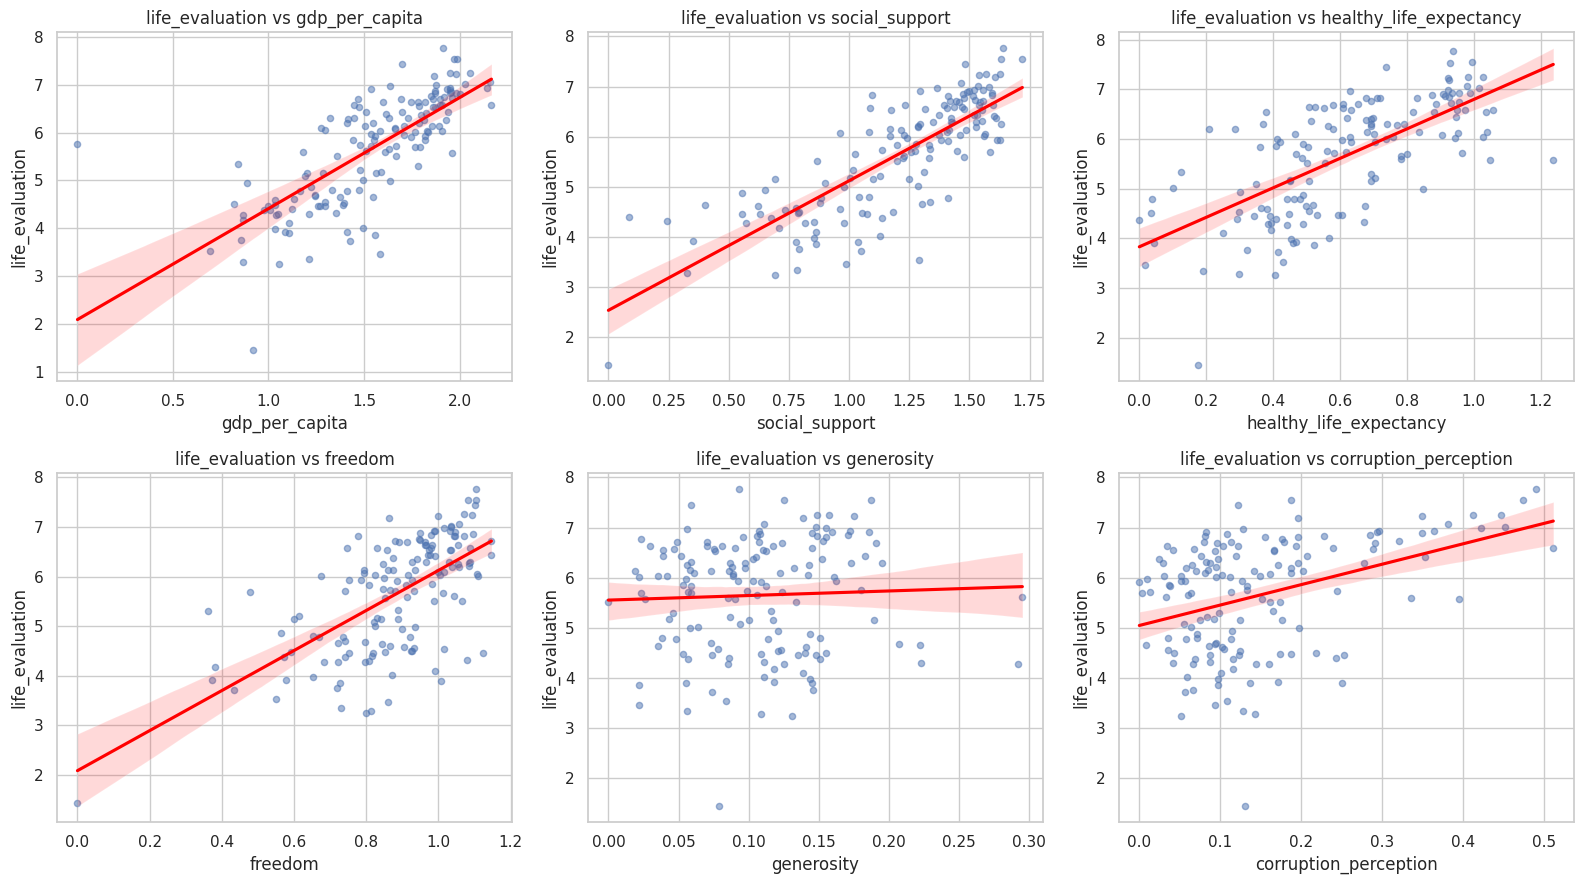

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, factor_cols):
    sns.regplot(data=df_2025, x=col, y="life_evaluation", ax=ax,
                scatter_kws={"alpha": 0.5, "s": 20}, line_kws={"color": "red"})
    ax.set_title(f"life_evaluation vs {col}")
plt.tight_layout()
plt.savefig("../visuals/happiness_vs_factors_2025.png", dpi=150)
plt.show()


**Interpretation to write after running:**
- Which factor has the strongest correlation with life evaluation?
- Are any relationships surprisingly weak (e.g. generosity)?
- Note: these are correlations, not causal effects — the report's own decomposition already attributes explanatory weight to each factor.


## 5. Trends Over Time (2011–2025)

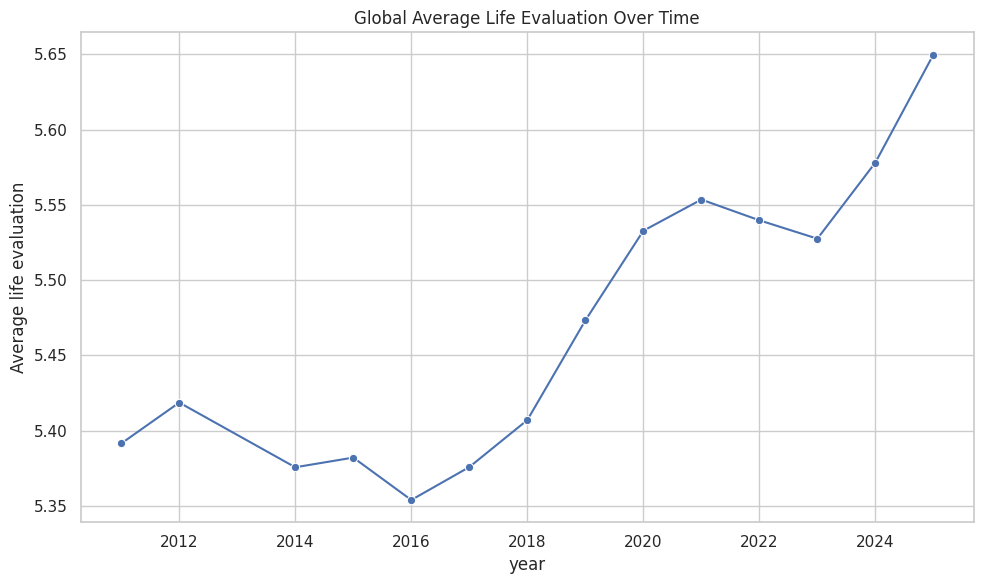

In [17]:
global_trend = df.groupby("year")["life_evaluation"].mean().reset_index()

fig, ax = plt.subplots()
sns.lineplot(data=global_trend, x="year", y="life_evaluation", marker="o", ax=ax)
ax.set_title("Global Average Life Evaluation Over Time")
ax.set_ylabel("Average life evaluation")
plt.tight_layout()
plt.savefig("../visuals/global_trend.png", dpi=150)
plt.show()


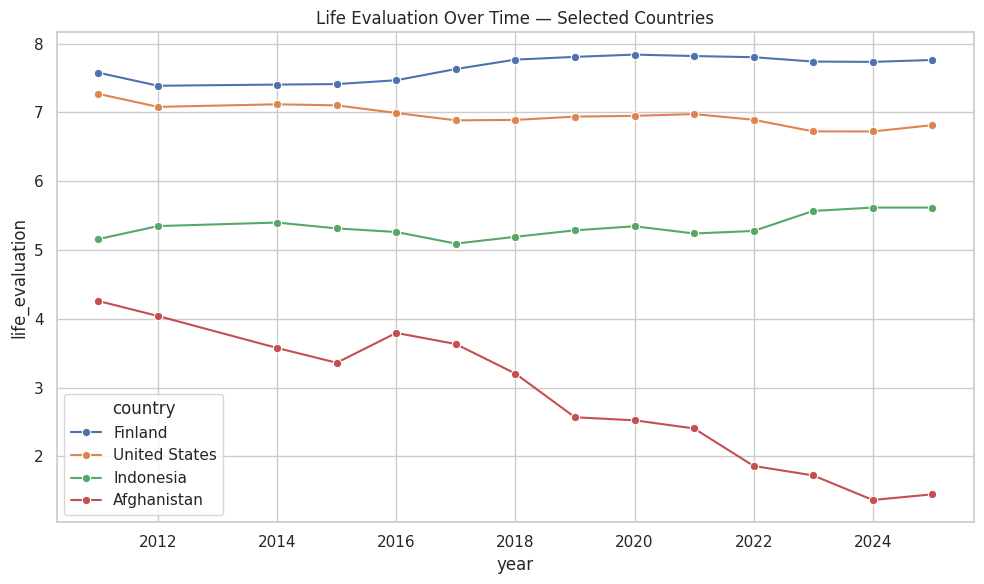

In [18]:
# Track a handful of countries over time for comparison — edit this list as needed
countries_of_interest = ["Finland", "United States", "Indonesia", "Afghanistan"]

subset = df[df["country"].isin(countries_of_interest)]

fig, ax = plt.subplots()
sns.lineplot(data=subset, x="year", y="life_evaluation", hue="country", marker="o", ax=ax)
ax.set_title("Life Evaluation Over Time — Selected Countries")
plt.tight_layout()
plt.savefig("../visuals/country_trends.png", dpi=150)
plt.show()


## 6. Key Insights (fill in after review)

- Insight 1:
- Insight 2:
- Insight 3:

## Limitations / Next Steps
- This dataset has no `region`/`continent` column — a regional comparison would need an external country→region mapping (e.g. UN M49 or `pycountry-convert`).
- Correlation ≠ causation; a regression model could quantify each factor's independent contribution.
- The "Social media & happiness" theme of WHR 2026 isn't covered here — the free Figure 2.1 data doesn't include social media variables.
